### Testing Contourpy

Documentation is [here](https://contourpy.readthedocs.io/en/v1.1.1/index.html). 

In [11]:
import numpy as np
from matplotlib import pyplot as plt
import contourpy
N = 101
x,y = np.meshgrid(np.linspace(-2,2,N), np.linspace(-2,2,N))
z = np.exp(-((x-2)**2+y**2))+np.exp(-((x+2)**2+y**2))

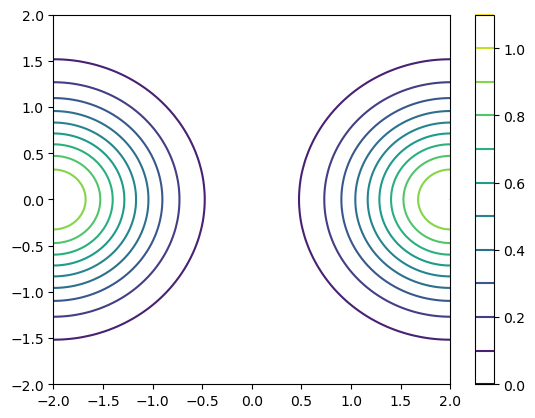

(101, 101) (101, 101) (101, 101)


In [13]:
fig,ax = plt.subplots()
cb=ax.contour(x,y,z, levels=10)
fig.colorbar(cb)
plt.show()

print(np.shape(x),np.shape(y),np.shape(z))

**Contourpy Usage**

The standard approach to use ContourPy is to:

Call `contour_generator()` passing your 2D `z` array and optional `x` and `y` arrays as arguments to return a `ContourGenerator` object, such as the default `SerialContourGenerator`.

Call `ContourGenerator` member functions `lines()` and/or `filled()` repeatedly to calculate and return contours for that (x, y, z) grid:

- `lines()` calculates contour lines at a particular z-level.
- `filled()` calculates filled contours (polygons) between two z-levels.

There are many arguments for `contour_generator()` but only z is compulsory and there are sensible defaults for the others.

In [3]:
contour_gen = contourpy.contour_generator(x,y,z)
contour_gen

In [24]:
#zlevel = 0.35
zlevels = np.linspace(np.min(z), np.max(z), 10)
zlevel = zlevels[5]
lines = contour_gen.lines(zlevel)
print(np.shape(lines))

(2, 79, 2)


In [25]:
xpoints_0 = lines[0][:,0]
ypoints_0 = lines[0][:,1]
xpoints_1 = lines[1][:,0]
ypoints_1 = lines[1][:,1]

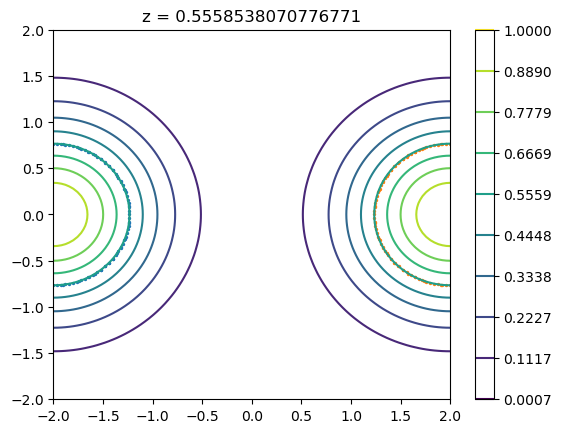

In [27]:
fig,ax = plt.subplots()
cb=ax.contour(x,y,z, levels=zlevels)
ax.scatter(xpoints_0, ypoints_0, s=2)
ax.scatter(xpoints_1, ypoints_1,s=2)
fig.colorbar(cb)
ax.set(title=f"z = {zlevel}")
plt.show()

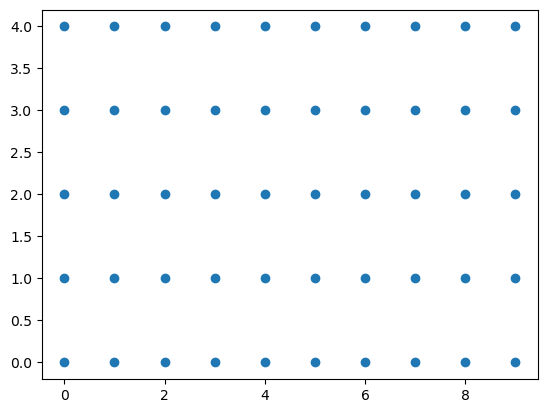

In [7]:
xg,yg = np.meshgrid(np.arange(0,10,1), np.arange(0,5,1))
fig,ax = plt.subplots()
ax.scatter(xg,yg)
plt.show()

z = np.ones((5, 10)) # Sample z data.
cont_gen = contourpy.contour_generator(z=z, chunk_size=(2, 2))


In [8]:
cont_gen.chunk_size

(2, 2)

In [9]:
cont_gen.chunk_count

(2, 5)

In the above code, specifying `chunk_size` or `chunk_count` sets the number of regions, or chunks, to subdivide the domain up into. Here, with `chunk_size = (2,2)`, there are two chunks in the vertical (y) direction, and 5 in the horizontal (x) direction, with each chunk consisting of a 2x2 collection of quads.